# Undersampling i oversampling klasy `unknown`

Notebook sprawdza wpływ fizycznego resamplowania zbioru treningowego na klasyfikację komend głosowych. Eksperyment porównuje rozkład naturalny z wariantem, w którym klasa `unknown` jest undersamplowana do liczności największej pozostałej klasy, oraz wariantem łączonym, w którym po takim undersamplingu mniejsze klasy są oversamplowane przez duplikację przykładów do tej samej liczności.

Walidacja i test zostają bez resamplowania. Dzięki temu metryki mierzą zachowanie modeli na naturalnym rozkładzie danych, a zmieniamy wyłącznie dane widziane w trakcie uczenia.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts import (
    DataFixedParams,
    DataGridParams,
    Experiment,
    FeatureFixedParams,
    FitFixedParams,
    FitGridParams,
    LABEL_ORDER,
    ModelGridParams,
    UNKNOWN_LABEL,
    experiment_grid_dataframe,
    expand_experiment_grid,
    prepare_experiment_data_files,
    train_experiment,
)
from scripts.data import PreparedDataFiles
from scripts.runner import data_key

LABEL_ORDER

('yes',
 'no',
 'up',
 'down',
 'left',
 'right',
 'on',
 'off',
 'stop',
 'go',
 'unknown',
 'silence')

## Konfiguracja

`unknown_fraction` jest ustawione na `0.03`, żeby klasa `unknown` nadal była większa od pojedynczych klas docelowych, ale żeby wariant oversamplingu nie tworzył niepraktycznie dużego zbioru treningowego. Konfiguracja używa obu architektur i małych modeli, więc powinna nadawać się do kilkuminutowego uruchomienia na CPU.

In [2]:
EPOCHS = 3
OUTPUT_DIR = "reports/05_sampling_experiment"
# Mały, sensowny run na CPU: obie architektury, trzy strategie i lekkie modele.
ARCHITECTURES = ["lstm", "transformer"]
SELECTED_STRATEGIES = [
    "natural",
    "unknown_undersampled",
    "undersampled_then_oversampled",
]

DATA_GRID_CONFIG = {
    "train_fraction": 0.03,
    "validation_fraction": 0.03,
    "test_fraction": 0.03,
    "unknown_fraction": 0.03,
    "silence_examples_per_split": 20,
    "sampling_strategy": "natural",
    "seed": 42,
}

FEATURE_CONFIG = {
    "n_mels": 48,
    "n_fft": 512,
    "hop_length": 320,
    "normalize": True,
}

FIT_FIXED_CONFIG = {
    "device": "cpu",
    "use_tqdm": True,
    "progress_backend": "terminal",
    "verbose": True,
    "early_stopping": True,
    "early_stopping_patience": 2,
    "early_stopping_min_delta": 0.001,
}

FIT_GRID_CONFIG = {
    "epochs": EPOCHS,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
}

MODEL_CONFIG = {
    "dropout": 0.15,
    "lstm_hidden_size": 64,
    "lstm_layers": 1,
    "lstm_bidirectional": True,
    "transformer_d_model": 64,
    "transformer_heads": 4,
    "transformer_layers": 1,
    "transformer_ff_dim": 128,
}

base_data_fixed = DataFixedParams(
    cache_dir=".cache/sampling_experiment_audio",
    output_dir=OUTPUT_DIR,
)
base_data_grid = DataGridParams(**DATA_GRID_CONFIG)
base_feature_fixed = FeatureFixedParams(**FEATURE_CONFIG)
base_fit_fixed = FitFixedParams(**FIT_FIXED_CONFIG)
base_fit_grid = FitGridParams(**FIT_GRID_CONFIG)

pd.DataFrame(
    [
        {"group": "data", **DATA_GRID_CONFIG},
        {"group": "features", **FEATURE_CONFIG},
        {"group": "fit", **FIT_FIXED_CONFIG, **FIT_GRID_CONFIG},
        {"group": "model", **MODEL_CONFIG},
    ]
)

,group,train_fraction,validation_fraction,test_fraction,unknown_fraction,silence_examples_per_split,sampling_strategy,seed,n_mels,n_fft,...,learning_rate,weight_decay,dropout,lstm_hidden_size,lstm_layers,lstm_bidirectional,transformer_d_model,transformer_heads,transformer_layers,transformer_ff_dim
0,data,0.03,0.03,0.03,0.03,20.0,natural,42.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,512.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001,0.0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.15,64.0,1.0,True,64.0,4.0,1.0,128.0


## Strategie resamplowania

Strategia `unknown_undersampled` losowo zmniejsza tylko klasę `unknown` do liczności największej klasy nie-`unknown`. Strategia `undersampled_then_oversampled` robi ten sam krok, a potem duplikuje przykłady z mniejszych klas, żeby każda klasa w treningu miała taką samą liczność.

Dodatkowo funkcja obsługuje wariant `oversampled_to_largest`, który duplikuje wszystkie mniejsze klasy do liczności największej klasy w danych wejściowych. Nie jest uruchamiany domyślnie, bo przy dużej klasie `unknown` może bardzo zwiększyć czas treningu.

In [3]:
def class_counts(manifest: pd.DataFrame) -> pd.Series:
    return manifest["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)


def largest_non_unknown_count(train_manifest: pd.DataFrame) -> int:
    counts = train_manifest[train_manifest["label"] != UNKNOWN_LABEL]["label"].value_counts()
    return int(counts.max())


def undersample_unknown(train_manifest: pd.DataFrame, seed: int) -> pd.DataFrame:
    target_count = largest_non_unknown_count(train_manifest)
    sampled_groups = []

    for label, group in train_manifest.groupby("label", sort=False):
        if label == UNKNOWN_LABEL and len(group) > target_count:
            sampled_groups.append(group.sample(n=target_count, random_state=seed))
        else:
            sampled_groups.append(group)

    return pd.concat(sampled_groups, ignore_index=True)


def oversample_to_count(train_manifest: pd.DataFrame, target_count: int, seed: int) -> pd.DataFrame:
    sampled_groups = []

    for label, group in train_manifest.groupby("label", sort=False):
        if len(group) >= target_count:
            sampled_groups.append(group.sample(n=target_count, random_state=seed) if len(group) > target_count else group)
            continue

        repetitions = target_count // len(group)
        remainder = target_count % len(group)
        parts = [group.copy() for _ in range(repetitions)]
        if remainder:
            parts.append(group.sample(n=remainder, replace=False, random_state=seed))
        sampled_groups.append(pd.concat(parts, ignore_index=True))

    resampled = pd.concat(sampled_groups, ignore_index=True)
    resampled["resample_copy_id"] = resampled.groupby(["label", "archive_path"]).cumcount()
    return resampled


def resample_train_manifest(train_manifest: pd.DataFrame, strategy: str, seed: int) -> pd.DataFrame:
    train_manifest = train_manifest.reset_index(drop=True).copy()

    if strategy == "natural":
        result = train_manifest
    elif strategy == "unknown_undersampled":
        result = undersample_unknown(train_manifest, seed)
    elif strategy == "undersampled_then_oversampled":
        undersampled = undersample_unknown(train_manifest, seed)
        target_count = int(undersampled["label"].value_counts().max())
        result = oversample_to_count(undersampled, target_count, seed)
    elif strategy == "oversampled_to_largest":
        target_count = int(train_manifest["label"].value_counts().max())
        result = oversample_to_count(train_manifest, target_count, seed)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    result = result.reset_index(drop=True).copy()
    result["balancing_strategy"] = strategy
    return result


def replace_train_manifest(prepared_files: PreparedDataFiles, train_manifest: pd.DataFrame) -> PreparedDataFiles:
    validation_manifest = prepared_files.validation_manifest.copy()
    test_manifest = prepared_files.test_manifest.copy()
    manifest = pd.concat([train_manifest, validation_manifest, test_manifest], ignore_index=True)

    return PreparedDataFiles(
        manifest=manifest,
        train_manifest=train_manifest,
        validation_manifest=validation_manifest,
        test_manifest=test_manifest,
        local_paths=prepared_files.local_paths,
    )

## Definicje eksperymentów

Każda strategia resamplowania jest trenowana osobno dla LSTM i Transformera. Architektury są takie same jak w poprzednich eksperymentach; zmienia się tylko rozkład danych treningowych.

In [4]:
def model_params_for(architecture: str) -> dict:
    return {
        "model_type": architecture,
        **MODEL_CONFIG,
    }


def make_experiment(strategy: str, architecture: str) -> Experiment:
    safe_strategy = strategy.replace("_", "-")
    return Experiment(
        name=f"05_sampling_{safe_strategy}_{architecture}",
        data_fixed=base_data_fixed,
        data_grid=base_data_grid,
        feature_fixed=base_feature_fixed,
        model_grid=ModelGridParams(**model_params_for(architecture)),
        fit_fixed=base_fit_fixed,
        fit_grid=base_fit_grid,
    )


experiments = {
    (strategy, architecture): make_experiment(strategy, architecture)
    for strategy in SELECTED_STRATEGIES
    for architecture in ARCHITECTURES
}

experiment_grid_dataframe(experiments[(SELECTED_STRATEGIES[0], ARCHITECTURES[0])])

,experiment,data.train_fraction,data.validation_fraction,data.test_fraction,data.unknown_fraction,data.silence_examples_per_split,data.sampling_strategy,data.seed,model.model_type,model.dropout,...,model.lstm_layers,model.lstm_bidirectional,model.transformer_d_model,model.transformer_heads,model.transformer_layers,model.transformer_ff_dim,fit.epochs,fit.batch_size,fit.learning_rate,fit.weight_decay
0,05_sampling_natural_lstm,0.03,0.03,0.03,0.03,20,natural,42,lstm,0.15,...,1,True,64,4,1,128,3,32,0.001,0.0001


## Przygotowanie danych

Najpierw przygotowywany jest jeden manifest bazowy. Następnie tworzymy jego warianty z różnymi rozkładami klas w treningu. Pliki audio pozostają te same, więc cache ekstrakcji archiwum jest współdzielony.

In [5]:
data_cache_experiment = make_experiment("data_cache", ARCHITECTURES[0])
base_prepared_files = prepare_experiment_data_files(data_cache_experiment, DATA_GRID_CONFIG)

base_distribution = pd.crosstab(base_prepared_files.manifest["label"], base_prepared_files.manifest["split"])
base_distribution.reindex(LABEL_ORDER, fill_value=0)

split,test,train,validation
label,,,
yes,8,56,8
no,8,56,9
up,9,56,8
down,8,56,8
left,9,56,8
right,8,56,8
on,8,56,8
off,8,56,8
stop,8,57,8


In [6]:
strategy_prepared_files = {}
strategy_distributions = []

for strategy in SELECTED_STRATEGIES:
    train_manifest = resample_train_manifest(
        base_prepared_files.train_manifest,
        strategy=strategy,
        seed=DATA_GRID_CONFIG["seed"],
    )
    strategy_prepared_files[strategy] = replace_train_manifest(base_prepared_files, train_manifest)

    counts = class_counts(train_manifest)
    for label, count in counts.items():
        strategy_distributions.append(
            {
                "strategy": strategy,
                "label": label,
                "train_count": int(count),
            }
        )

strategy_distribution = pd.DataFrame(strategy_distributions)
strategy_distribution.pivot(index="label", columns="strategy", values="train_count").reindex(LABEL_ORDER)

strategy,natural,undersampled_then_oversampled,unknown_undersampled
label,,,
yes,56,57,56
no,56,57,56
up,56,57,56
down,56,57,56
left,56,57,56
right,56,57,56
on,56,57,56
off,56,57,56
stop,57,57,57


## Uruchomienie eksperymentów

Ta komórka uruchamia wszystkie strategie z `SELECTED_STRATEGIES` dla obu architektur. Wyniki każdego treningu są zapisywane w osobnym katalogu, a wspólne podsumowanie trafia do `reports/05_sampling_experiment/sampling_experiment_summary.csv`.

In [7]:
all_results = []

for strategy in SELECTED_STRATEGIES:
    prepared_files = strategy_prepared_files[strategy]

    for architecture in ARCHITECTURES:
        experiment = experiments[(strategy, architecture)]
        run = expand_experiment_grid(experiment)[0]
        prepared_by_key = {data_key(run): prepared_files}

        print(f"[{strategy} | {architecture}]")
        summary = train_experiment(experiment, prepared_by_key).copy()
        summary.insert(0, "strategy", strategy)
        summary.insert(1, "architecture", architecture)
        summary.insert(2, "train_examples", len(prepared_files.train_manifest))
        summary.insert(3, "unknown_train_examples", int((prepared_files.train_manifest["label"] == UNKNOWN_LABEL).sum()))
        all_results.append(summary)

all_results = pd.concat(all_results, ignore_index=True)
summary_path = Path(OUTPUT_DIR) / "sampling_experiment_summary.csv"
summary_path.parent.mkdir(parents=True, exist_ok=True)
all_results.to_csv(summary_path, index=False)
all_results.sort_values("test_accuracy", ascending=False)

[natural | lstm]
Starting experiment: 05_sampling_natural_lstm

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.03
  - validation_fraction: 0.03
  - test_fraction: 0.03
  - unknown_fraction: 0.03
  - silence_examples_per_split: 20
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: lstm
  - dropout: 0.15
  - lstm_hidden_size: 64
  - lstm_layers: 1
  - lstm_bidirectional: True
  - transformer_d_model: 64
  - transformer_heads: 4
  - transformer_layers: 1
  - transformer_ff_dim: 128
FIT (variable):
  - epochs: 3
  - batch_size: 32
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cpu


Training: 100%|██████████| 3/3 [00:24<00:00,  8.21s/it, loss=1.4169, lr=0.001, val_acc=0.6077, val_loss=1.4239]


Training finished in 25.66 seconds



Experiment finished | total runs = 1
[natural | transformer]
Starting experiment: 05_sampling_natural_transformer

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.03
  - validation_fraction: 0.03
  - test_fraction: 0.03
  - unknown_fraction: 0.03
  - silence_examples_per_split: 20
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.15
  - lstm_hidden_size: 64
  - lstm_layers: 1
  - lstm_bidirectional: True
  - transformer_d_model: 64
  - transformer_heads: 4
  - transformer_layers: 1
  - transformer_ff_dim: 128
FIT (variable):
  - epochs: 3
  - batch_size: 32
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cpu


Training: 100%|██████████| 3/3 [00:25<00:00,  8.62s/it, loss=1.3110, lr=0.001, val_acc=0.6459, val_loss=1.2221]


Training finished in 26.83 seconds



Experiment finished | total runs = 1
[unknown_undersampled | lstm]
Starting experiment: 05_sampling_unknown-undersampled_lstm

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.03
  - validation_fraction: 0.03
  - test_fraction: 0.03
  - unknown_fraction: 0.03
  - silence_examples_per_split: 20
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: lstm
  - dropout: 0.15
  - lstm_hidden_size: 64
  - lstm_layers: 1
  - lstm_bidirectional: True
  - transformer_d_model: 64
  - transformer_heads: 4
  - transformer_layers: 1
  - transformer_ff_dim: 128
FIT (variable):
  - epochs: 3
  - batch_size: 32
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cpu


...

Training: 100%|██████████| 3/3 [00:15<00:00,  5.03s/it, loss=2.0849, lr=0.001, val_acc=0.1675, val_loss=2.3363]


Training finished in 16.21 seconds



Experiment finished | total runs = 1
[undersampled_then_oversampled | transformer]
Starting experiment: 05_sampling_undersampled-then-oversampled_transformer

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.03
  - validation_fraction: 0.03
  - test_fraction: 0.03
  - unknown_fraction: 0.03
  - silence_examples_per_split: 20
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.15
  - lstm_hidden_size: 64
  - lstm_layers: 1
  - lstm_bidirectional: True
  - transformer_d_model: 64
  - transformer_heads: 4
  - transformer_layers: 1
  - transformer_ff_dim: 128
FIT (variable):
  - epochs: 3
  - batch_size: 32
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cpu


Training: 100%|██████████| 3/3 [00:15<00:00,  5.21s/it, loss=2.0134, lr=0.001, val_acc=0.1388, val_loss=2.1736]


Training finished in 16.50 seconds



Experiment finished | total runs = 1


,strategy,architecture,train_examples,unknown_train_examples,run,best_epoch,epochs_trained,stopped_early,train_loss,train_accuracy,validation_loss,validation_accuracy,test_loss,test_accuracy
1,natural,transformer,1539,977,trfm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,1.311002,0.641326,1.222133,0.645933,1.333632,0.613208
0,natural,lstm,1539,977,lstm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,1.416931,0.634828,1.423895,0.607656,1.452771,0.608491
3,unknown_undersampled,transformer,619,57,trfm_train0_03_val0_03_test0_03_lr0_001_seed42,2,3,False,2.333867,0.166397,2.262948,0.181818,2.283711,0.212264
4,undersampled_then_oversampled,lstm,684,57,lstm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,2.084931,0.359649,2.336313,0.167464,2.364282,0.155660
2,unknown_undersampled,lstm,619,57,lstm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,2.256092,0.294023,2.300532,0.153110,2.339147,0.150943
5,undersampled_then_oversampled,transformer,684,57,trfm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,2.013436,0.274854,2.173616,0.138756,2.201370,0.141509


## Wczytanie zapisanych wyników

Jeśli trening został już wykonany, ta komórka pozwala wrócić do analizy bez ponownego uruchamiania modeli.

In [8]:
summary_path = Path(OUTPUT_DIR) / "sampling_experiment_summary.csv"

if summary_path.exists():
    all_results = pd.read_csv(summary_path)

all_results.sort_values("test_accuracy", ascending=False)

,strategy,architecture,train_examples,unknown_train_examples,run,best_epoch,epochs_trained,stopped_early,train_loss,train_accuracy,validation_loss,validation_accuracy,test_loss,test_accuracy
1,natural,transformer,1539,977,trfm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,1.311002,0.641326,1.222133,0.645933,1.333632,0.613208
0,natural,lstm,1539,977,lstm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,1.416931,0.634828,1.423895,0.607656,1.452771,0.608491
3,unknown_undersampled,transformer,619,57,trfm_train0_03_val0_03_test0_03_lr0_001_seed42,2,3,False,2.333867,0.166397,2.262948,0.181818,2.283711,0.212264
4,undersampled_then_oversampled,lstm,684,57,lstm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,2.084931,0.359649,2.336313,0.167464,2.364282,0.155660
2,unknown_undersampled,lstm,619,57,lstm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,2.256092,0.294023,2.300532,0.153110,2.339147,0.150943
5,undersampled_then_oversampled,transformer,684,57,trfm_train0_03_val0_03_test0_03_lr0_001_seed42,3,3,False,2.013436,0.274854,2.173616,0.138756,2.201370,0.141509


## Analiza wyników

Najważniejsze porównanie to `test_accuracy` między strategiami dla tej samej architektury. Dodatkowo warto patrzeć na `epochs_trained` i `stopped_early`, bo mocne resamplowanie zmienia liczbę batchy oraz dynamikę walidacji.

In [9]:
columns = [
    "strategy",
    "architecture",
    "train_examples",
    "unknown_train_examples",
    "test_accuracy",
    "validation_accuracy",
    "best_epoch",
    "epochs_trained",
    "stopped_early",
]

all_results[columns].sort_values(["architecture", "test_accuracy"], ascending=[True, False])

,strategy,architecture,train_examples,unknown_train_examples,test_accuracy,validation_accuracy,best_epoch,epochs_trained,stopped_early
0,natural,lstm,1539,977,0.608491,0.607656,3,3,False
4,undersampled_then_oversampled,lstm,684,57,0.155660,0.167464,3,3,False
2,unknown_undersampled,lstm,619,57,0.150943,0.153110,3,3,False
1,natural,transformer,1539,977,0.613208,0.645933,3,3,False
3,unknown_undersampled,transformer,619,57,0.212264,0.181818,2,3,False
5,undersampled_then_oversampled,transformer,684,57,0.141509,0.138756,3,3,False


In [10]:
accuracy_table = all_results.pivot_table(
    index="strategy",
    columns="architecture",
    values="test_accuracy",
    aggfunc="max",
).reindex(SELECTED_STRATEGIES)

accuracy_table

architecture,lstm,transformer
strategy,,
natural,0.608491,0.613208
unknown_undersampled,0.150943,0.212264
undersampled_then_oversampled,0.155660,0.141509


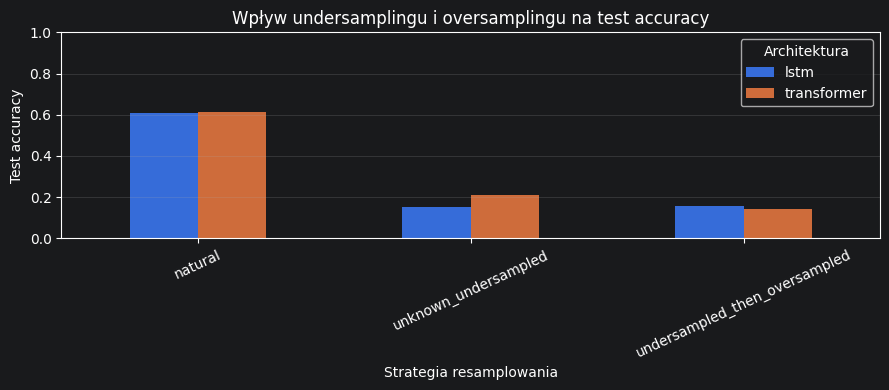

In [11]:
axis = accuracy_table.plot(kind="bar", figsize=(9, 4), ylim=(0, 1), rot=25)
axis.set_title("Wpływ undersamplingu i oversamplingu na test accuracy")
axis.set_xlabel("Strategia resamplowania")
axis.set_ylabel("Test accuracy")
axis.grid(axis="y", alpha=0.25)
axis.legend(title="Architektura")
plt.tight_layout()
plt.show()

## Krótka interpretacja do raportu

W raporcie porównaj `natural`, `unknown_undersampled` i `undersampled_then_oversampled` osobno dla LSTM i Transformera. Jeśli `unknown_undersampled` poprawia klasy docelowe, ale obniża wynik ogólny, oznacza to zwykle utratę informacji o zróżnicowanej klasie `unknown`. Jeśli wariant z oversamplingiem nie poprawia accuracy, duplikacja mniejszych klas prawdopodobnie nie dodaje informacji, a tylko zmienia częstość ich obserwowania przez model.